# Teen Phone Addiction Dataset - Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("teen_phone_addiction_dataset.csv")
df.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [3]:
df.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [4]:
for col in df.columns:
    print(f"{col:35} : {df[col].nunique()} unique values")

ID                                  : 3000 unique values
Name                                : 2933 unique values
Age                                 : 7 unique values
Gender                              : 3 unique values
Location                            : 2726 unique values
School_Grade                        : 6 unique values
Daily_Usage_Hours                   : 107 unique values
Sleep_Hours                         : 71 unique values
Academic_Performance                : 51 unique values
Social_Interactions                 : 11 unique values
Exercise_Hours                      : 39 unique values
Anxiety_Level                       : 10 unique values
Depression_Level                    : 10 unique values
Self_Esteem                         : 10 unique values
Parental_Control                    : 2 unique values
Screen_Time_Before_Bed              : 27 unique values
Phone_Checks_Per_Day                : 131 unique values
Apps_Used_Daily                     : 16 unique values
Time_o

In [5]:
# Relevant columns
cols = [
    'Age',
    'Gender',
    'School_Grade',
    'Daily_Usage_Hours',
    'Sleep_Hours',
    'Academic_Performance',
    'Social_Interactions',
    'Exercise_Hours',
    'Anxiety_Level',
    'Depression_Level',
    'Self_Esteem',
    'Screen_Time_Before_Bed',
    'Phone_Checks_Per_Day',
    'Apps_Used_Daily',
    'Time_on_Social_Media',
    'Addiction_Level'
]

# Missingness
print("Missingness\n")

missing_data = []
for col in cols:
    non_missing = df[col].notna().sum()
    missing = df[col].isna().sum()
    pct = (missing / len(df)) * 100
    missing_data.append([col, non_missing, missing, round(pct, 2)])

missing_df = pd.DataFrame(missing_data, columns=["Field", "Non-missing", "Missing", "Missing %"])
print(missing_df.to_string(index=False))

Missingness

                 Field  Non-missing  Missing  Missing %
                   Age         3000        0        0.0
                Gender         3000        0        0.0
          School_Grade         3000        0        0.0
     Daily_Usage_Hours         3000        0        0.0
           Sleep_Hours         3000        0        0.0
  Academic_Performance         3000        0        0.0
   Social_Interactions         3000        0        0.0
        Exercise_Hours         3000        0        0.0
         Anxiety_Level         3000        0        0.0
      Depression_Level         3000        0        0.0
           Self_Esteem         3000        0        0.0
Screen_Time_Before_Bed         3000        0        0.0
  Phone_Checks_Per_Day         3000        0        0.0
       Apps_Used_Daily         3000        0        0.0
  Time_on_Social_Media         3000        0        0.0
       Addiction_Level         3000        0        0.0


In [6]:
# Daily Usage Distribution
print("Daily Usage Distribution\n")
usage_bins = pd.cut(df['Daily_Usage_Hours'], bins=[0,2,4,6,10], labels=["Low","Moderate","High","Very High"])
usage_dist = usage_bins.value_counts().sort_index()
usage_pct = usage_bins.value_counts(normalize=True).sort_index()*100

usage_table = pd.DataFrame({"Count": usage_dist, "Percent": usage_pct.round(2)})
print(usage_table)

Daily Usage Distribution

                   Count  Percent
Daily_Usage_Hours                
Low                  168     5.68
Moderate             723    24.45
High                1168    39.50
Very High            898    30.37


In [7]:
# Depression Level
print("Depression Level Distribution\n")
depression_dist = df['Depression_Level'].value_counts().sort_index()
depression_pct = df['Depression_Level'].value_counts(normalize=True).sort_index()*100

depression_table = pd.DataFrame({"Count": depression_dist, "Percent": depression_pct.round(2)})
print(depression_table)

Depression Level Distribution

                  Count  Percent
Depression_Level                
1                   328    10.93
2                   278     9.27
3                   290     9.67
4                   312    10.40
5                   304    10.13
6                   315    10.50
7                   298     9.93
8                   282     9.40
9                   303    10.10
10                  290     9.67


In [8]:
print("Binary Association: High Usage vs Depression Level\n")

# Define binary groups
df['High_Usage'] = df['Daily_Usage_Hours'] > df['Daily_Usage_Hours'].median()
df['Poor_Mental_Health'] = df['Depression_Level'] >= df['Depression_Level'].median()

valid = df.dropna(subset=['High_Usage', 'Poor_Mental_Health'])

ct = pd.crosstab(valid['High_Usage'], valid['Poor_Mental_Health'])
print(ct)

# Percentages
high_usage_rate = ct.loc[True, True] / ct.loc[True].sum()
low_usage_rate = ct.loc[False, True] / ct.loc[False].sum()

print(f"\nPoor mental health among high usage: {high_usage_rate*100:.2f}%")
print(f"Poor mental health among low usage: {low_usage_rate*100:.2f}%")


Binary Association: High Usage vs Depression Level

Poor_Mental_Health  False  True 
High_Usage                      
False                 628    917
True                  580    875

Poor mental health among high usage: 60.14%
Poor mental health among low usage: 59.35%


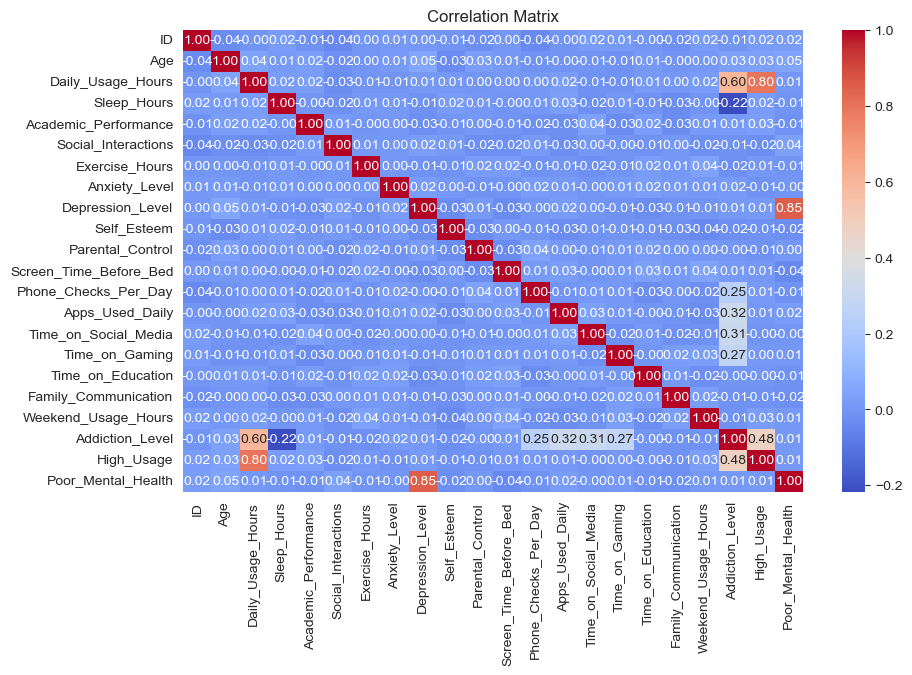

In [9]:
# Correlation matrix
plt.figure(figsize=(10, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

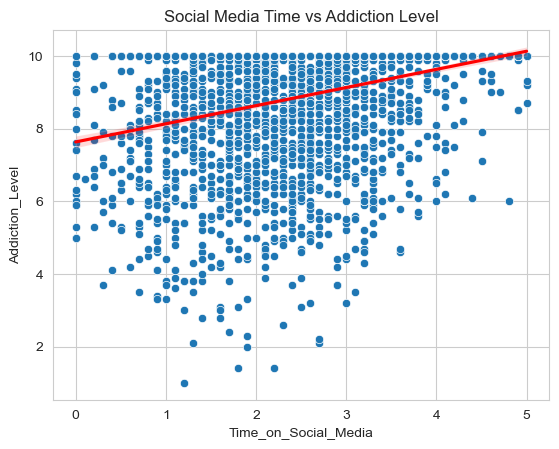

In [10]:
# Social media vs addiction
plt.figure()
sns.scatterplot(x='Time_on_Social_Media', y='Addiction_Level', data=df)
sns.regplot(x='Time_on_Social_Media', y='Addiction_Level', data=df, scatter=False, color='red')
plt.title("Social Media Time vs Addiction Level")
plt.show()

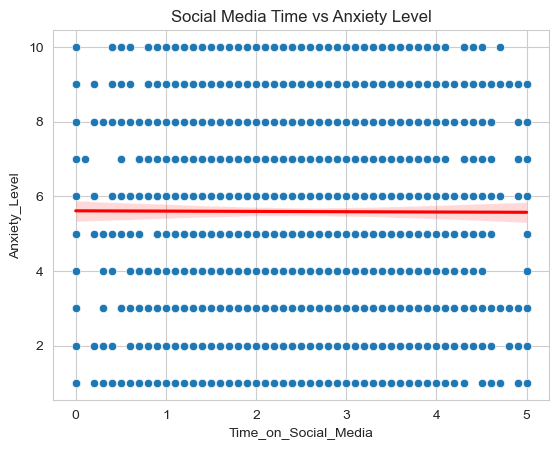

In [11]:
# Social media vs anxiety
plt.figure()
sns.scatterplot(x='Time_on_Social_Media', y='Anxiety_Level', data=df)
sns.regplot(x='Time_on_Social_Media', y='Anxiety_Level', data=df, scatter=False, color='red')
plt.title("Social Media Time vs Anxiety Level")
plt.show()

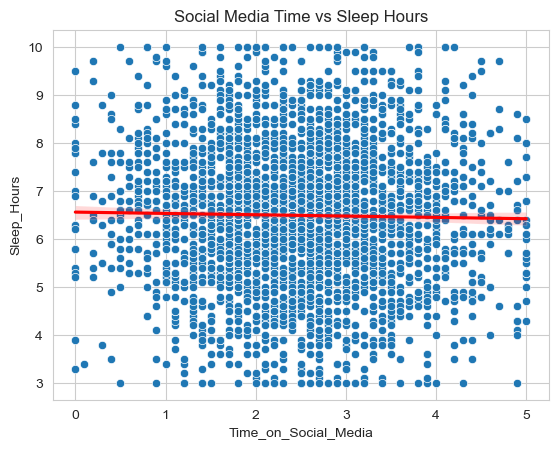

In [12]:
# Social media vs sleep
plt.figure()
sns.scatterplot(x='Time_on_Social_Media', y='Sleep_Hours', data=df)
sns.regplot(x='Time_on_Social_Media', y='Sleep_Hours', data=df, scatter=False, color='red')
plt.title("Social Media Time vs Sleep Hours")
plt.show()

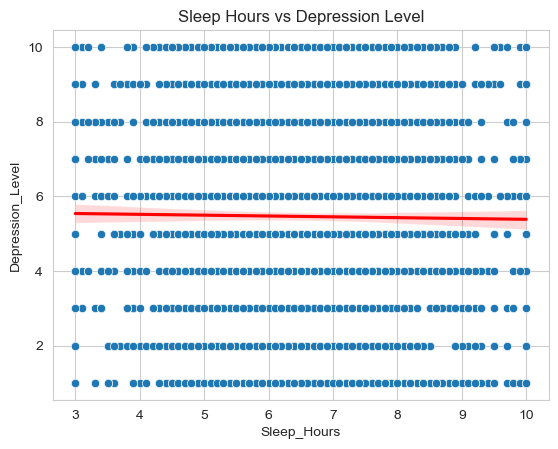

In [13]:
# Social media vs depression
plt.figure()
sns.scatterplot(x='Sleep_Hours', y='Depression_Level', data=df)
sns.regplot(x='Sleep_Hours', y='Depression_Level', data=df, scatter=False, color='red')
plt.title("Sleep Hours vs Depression Level")
plt.show()

In [14]:
# Summary correlations
print("\nKey correlations:")
print("Social Media vs Addiction:", corr.loc['Time_on_Social_Media', 'Addiction_Level'])
print("Social Media vs Anxiety:", corr.loc['Time_on_Social_Media', 'Anxiety_Level'])
print("Social Media vs Sleep:", corr.loc['Time_on_Social_Media', 'Sleep_Hours'])
print("Sleep vs Depression:", corr.loc['Sleep_Hours', 'Depression_Level'])


Key correlations:
Social Media vs Addiction: 0.3065781914244708
Social Media vs Anxiety: -0.002736476029054909
Social Media vs Sleep: -0.01828776644330279
Sleep vs Depression: -0.01151822169529936


This notebook provides a preliminary exploration of the dataset, aiming to get an initial understanding of teenage phone usage and its relationship with factors such as anxiety levels, depression, academic performance, sleep duration, and other lifestyle indicators.